In [1]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


# Background
Grab merupakan salah satu perusahaan teknologi di Asia Tenggara yang kita kenal melalui aplikasinya dan digunakan hampir setiap hari untuk mengantar penumpang hingga makanan atau barang lainnya (by order). Salah satu strategi untuk mendominasi pasar Asia Tenggara, Grab meluncurkan GrabUnlimited untuk pelanggan berayar (subscription) pada layanan GrabFood, dimana user mendapat kupon diskon khusus. Sayangnya hal ini memiliki celah yang digunakan oleh sindikat fraudster dengan membuat resto fiktif yang memiliki menu makanan/minuman mahal, akun pembeli palsu, hingga menggunakan driver yang disuap untuk diam, serta adanya bug dimana aplikasi GrabFood Merchant bisa secara otomatis menyelesaikan pesanan dalam hitungan detik tanpa menunggu driver tiba di titik penjemputan. Integrasi hal ini membuat Grab rugi karena harus membayar subsidi kupon-kupon digunakan oleh sindikat fraudster dan juga merugikan driver organik yang mendapat pesanan fiktif.

# Problem Statement & Objectives
Kerugian masif akibat sindikat fraudster ini membuat Grab harus **mengidentifikasi karakteristik order GrabFood fiktif** sebagai langkah awal mencegah kerugian lebih lanjut. Sehingga Grab dapat menentukan strategi agar:
- **Mencegah sindikat melakukan kejahatan kembali**
- **Melindungi driver organik dari pesanan fiktif**

# Data Understanding
Sebagai perusahaan teknologi, tentunya Grab telah memiliki sistem penyimpanan data yang dapat menjadi jawaban dari masalah yang sedang dihadapi. Data dapat diakses [disini](https://drive.google.com/drive/folders/1I7yn_qaw5rQAWFFODtp-Z8JinWqOfVck).

note:
- numpy : komputasi numerik dan operasi matematika tingkat lanjut
- pandas : pengolahan data tabular
- matplotlib.pyplot : membuat grafik dan visualisasi 2D di Python
- seaborn : visualisasi data berbasis Matplotlib, tampilan yang lebih modern & estetis (heatmap, boxplot, distribution plot)
- plotly.express : grafik interaktif (bisa di-zoom, digeser, dan memunculkan info saat kursor diarahkan ke grafik)
- import warnings   warnings.filterwarnings("ignore") : Menyembunyikan pesan peringatan (warning)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chisquare

In [3]:
# selalu copy dulu dataset asli, utk mencegah kehilangan data
df_ori = pd.read_csv('grab_food_orders.csv')
df = df_ori.copy()
display(df.head(),df.tail())

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,NaN,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-ORD-00000002,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaN
2,GF-ORD-00000003,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaN
3,GF-ORD-00000004,GF-05867,GB-021929,Completed,30000,NaN,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-ORD-00000005,GF-06915,GB-008802,DONE,0,NaN,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
299995,GF-ORD-00299996,GF-03184,GB-009630,Completed,0,NaN,2024-03-05 08:36:00,2024-03-05 08:53:00,2024-03-05 09:08:00
299996,GF-ORD-00299997,GF-07218,GB-030429,Completed,0,NaN,2024-03-26 12:39:00,2024-03-26 12:51:00,2024-03-26 13:06:00
299997,GF-ORD-00299998,GF-06076,GB-009129,Completed,20000,NaN,2024-03-07 19:38:00,2024-03-07 19:45:00,2024-03-07 20:01:00
299998,GF-ORD-00299999,GF-07674,GB-029792,DONE,0,NaN,2023-11-05 09:05:00,2023-11-05 09:12:00,2023-11-05 09:45:00
299999,GF-ORD-00300000,GF-05894,GB-002245,Completed,30000,NaN,2024-03-16 11:05:00,2024-03-16 11:15:00,2024-03-16 11:27:00


In [4]:
df.shape

(300000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   order_id             300000 non-null  object
 1   merchant_id          300000 non-null  object
 2   user_id              300000 non-null  object
 3   order_status         300000 non-null  object
 4   promo_discount       300000 non-null  int64 
 5   cancel_reason        35780 non-null   object
 6   order_time           300000 non-null  object
 7   driver_arrived_time  270320 non-null  object
 8   completed_time       240093 non-null  object
dtypes: int64(1), object(8)
memory usage: 20.6+ MB


Profil data pesanan GrabFood memiliki 300.000 baris dan 9 kolom dengan nama:
- `order_id`: ID unik pesanan.
- `merchant_id`: ID resto.
- `user_id`: ID pelanggan.
- `order_status`: Status akhir .
- `promo_discount`: Nominal diskon yang dipakai.
- `cancel_reason`: Alasan pembatalan.
- `order_time`: Jam pelanggan klik pesan.
- `driver_arrived_time`: Jam driver sampai di resto untuk ambil makanan.
- `completed_time`: Jam makanan selesai diantar ke pembeli.

Terdapat kolom dengan jumlah baris yang tidak mencapai 300.000 diduga sebagai missing value / memang diisi kosong.


## Unique Data
Untuk melihat setiap value unik yang ada di tiap kolom, membantu untuk melihat profil data lebih jauh.

In [6]:
# ringkasan profil tiap kolom
# top = modus

# awal tampil describe, kolom `promo_discount` malah jadi pangkat, nah disini dibuat format desimal 0, supaya balik ke semula
# pd.options.display.float_format = '{:.0f}'.format >> ini malah bakal utk semua blok

display(df.describe(include='object'))
display(df.describe().style.format('{:.0f}'))

,order_id,merchant_id,user_id,order_status,cancel_reason,order_time,driver_arrived_time,completed_time
count,300000,300000,300000,300000,35780,300000,270320,240093
unique,300000,8000,39978,7,4,129984,127363,122206
top,GF-ORD-00000001,GF-02769,GB-004076,Completed,Resto Tutup,2023-11-24 09:54:00,2024-02-10 17:43:00,2024-01-28 21:01:00
freq,1,63,21,179697,11920,11,10,10


,promo_discount
count,300000
mean,60352
std,701843
min,-5000
25%,0
50%,10000
75%,20000
max,9999999


In [7]:
# data unik tiap kolom
# buat dulu wadah kosong untuk menampung data
uniqueList = []

# looping semua data yg unik di tiap kolom
for uniqCol in df.columns:
    uniqueList.append({
        'Column Name' : uniqCol,
        'Number of Unique' : df[uniqCol].nunique(),
        'Unique Values' : list(df[uniqCol].unique())
    })

# masukin yg udh di looping ke df baru
df_unique = pd.DataFrame(uniqueList)

# supaya semua yg unik dimunculin tanpa terpotong
# pandas secara default ngebatesin 50 karakter, nnti yg lain cuma muncul titik2 (....)
# singkatnya ini semacem Autofit table gtu
# dsni ternyta msh ada y terpotong, tp gpp msh bisa terlihat, krn memang terlalu byk yg unik jg datanya, ga perlu jg liat semuanya (kya ID)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_unique

,Column Name,Number of Unique,Unique Values
0,order_id,300000,"[GF-ORD-00000001, GF-ORD-00000002, GF-ORD-00000003, GF-ORD-00000004, GF-ORD-00000005, GF-ORD-00000006, GF-ORD-00000007, GF-ORD-00000008, GF-ORD-00000009, GF-ORD-00000010, GF-ORD-00000011, GF-ORD-00000012, GF-ORD-00000013, GF-ORD-00000014, GF-ORD-00000015, GF-ORD-00000016, GF-ORD-00000017, GF-ORD-00000018, GF-ORD-00000019, GF-ORD-00000020, GF-ORD-00000021, GF-ORD-00000022, GF-ORD-00000023, GF-ORD-00000024, GF-ORD-00000025, GF-ORD-00000026, GF-ORD-00000027, GF-ORD-00000028, GF-ORD-00000029, GF-ORD-00000030, GF-ORD-00000031, GF-ORD-00000032, GF-ORD-00000033, GF-ORD-00000034, GF-ORD-00000035, GF-ORD-00000036, GF-ORD-00000037, GF-ORD-00000038, GF-ORD-00000039, GF-ORD-00000040, GF-ORD-00000041, GF-ORD-00000042, GF-ORD-00000043, GF-ORD-00000044, GF-ORD-00000045, GF-ORD-00000046, GF-ORD-00000047, GF-ORD-00000048, GF-ORD-00000049, GF-ORD-00000050, GF-ORD-00000051, GF-ORD-00000052, GF-ORD-00000053, GF-ORD-00000054, GF-ORD-00000055, GF-ORD-00000056, GF-ORD-00000057, GF-ORD-00000058, GF-ORD-00000059, GF-ORD-00000060, GF-ORD-00000061, GF-ORD-00000062, GF-ORD-00000063, GF-ORD-00000064, GF-ORD-00000065, GF-ORD-00000066, GF-ORD-00000067, GF-ORD-00000068, GF-ORD-00000069, GF-ORD-00000070, GF-ORD-00000071, GF-ORD-00000072, GF-ORD-00000073, GF-ORD-00000074, GF-ORD-00000075, GF-ORD-00000076, GF-ORD-00000077, GF-ORD-00000078, GF-ORD-00000079, GF-ORD-00000080, GF-ORD-00000081, GF-ORD-00000082, GF-ORD-00000083, GF-ORD-00000084, GF-ORD-00000085, GF-ORD-00000086, GF-ORD-00000087, GF-ORD-00000088, GF-ORD-00000089, GF-ORD-00000090, GF-ORD-00000091, GF-ORD-00000092, GF-ORD-00000093, GF-ORD-00000094, GF-ORD-00000095, GF-ORD-00000096, GF-ORD-00000097, GF-ORD-00000098, GF-ORD-00000099, GF-ORD-00000100, ...]"
1,merchant_id,8000,"[GF-06555, GF-07698, GF-02054, GF-05867, GF-06915, GF-02913, GF-06096, GF-05908, GF-07980, GF-03354, GF-04756, GF-05325, GF-05000, GF-01186, GF-05206, GF-02952, GF-02912, GF-06999, GF-03803, GF-07503, GF-02639, GF-04019, GF-01681, GF-02509, GF-07570, GF-05029, GF-03386, GF-05739, GF-07854, GF-03308, GF-00846, GF-01725, GF-01792, GF-05495, GF-06478, GF-02961, GF-06524, GF-06779, GF-07595, GF-04193, GF-04880, GF-07360, GF-01606, GF-02222, GF-01894, GF-07197, GF-06519, GF-03390, GF-05860, GF-06150, GF-06715, GF-02955, GF-04124, GF-07851, GF-07666, GF-03686, GF-07056, GF-07642, GF-04388, GF-05021, GF-07364, GF-04745, GF-05589, GF-01054, GF-07932, GF-06372, GF-05469, GF-07391, GF-01066, GF-07099, GF-05231, GF-00031, GF-02678, GF-03208, GF-05357, GF-05233, GF-02885, GF-07231, GF-05863, GF-02934, GF-00620, GF-04787, GF-04519, GF-01904, GF-03934, GF-02991, GF-06655, GF-00405, GF-02501, GF-01403, GF-03637, GF-01714, GF-03738, GF-01601, GF-05077, GF-02834, GF-04216, GF-07034, GF-04882, GF-07054, ...]"
2,user_id,39978,"[GB-019659, GB-019520, GB-030006, GB-021929, GB-008802, GB-017153, GB-029338, GB-004497, GB-038538, GB-000749, GB-003625, GB-009244, GB-003623, GB-037852, GB-019939, GB-028833, GB-010858, GB-036291, GB-003751, GB-015000, GB-022493, GB-035291, GB-030350, GB-024959, GB-013509, GB-025202, GB-008396, GB-022141, GB-005324, GB-026424, GB-014120, GB-033712, GB-033206, GB-035189, GB-018308, GB-004310, GB-009889, GB-020617, GB-002843, GB-037912, GB-036935, GB-031492, GB-031131, GB-030035, GB-000364, GB-022198, GB-009274, GB-022958, GB-000154, GB-033406, GB-018958, GB-028017, GB-008376, GB-031859, GB-031560, GB-000035, GB-009382, GB-015560, GB-003599, GB-030900, GB-035597, GB-029605, GB-015037, GB-037414, GB-034204, GB-002964, GB-026823, GB-033442, GB-028458, GB-037422, GB-006597, GB-033381, GB-029712, GB-026014, GB-035465, GB-002220, GB-029013, GB-029940, GB-021631, GB-037091, GB-001502, GB-011308, GB-011380, GB-000253, GB-014920, GB-001749, GB-025786, GB-039029, GB-020516, GB-034996, GB-024452, GB-016437, GB-021858, GB-001879, GB-002279, GB-019477, GB-036991, GB-032702, GB-009043, GB-030215, ...]"
3,order_status,7,"[Completed, Cancel, CANCELED, DONE, Selesai, batal, Failed]"


## Data Profile
Setelah melihat keseluruhan data, diketahui:
- Terdapat 300.000 baris dan 9 kolom
- Terdapat beberapa kolom yang memiliki missing value yang ditampilkan dengan NaN : `cancel_reason`, `driver_arrived_time`, `completed_time`
- Kolom `order_id` berisi identitas unik setiap pesanan dan pastinya unik, namun tidak relevan dengan analisis data, sehingga dapat dieliminasi
- Kolom `promo_discount` memiliki range yang sangat lebar dari -5000 sampai 9999999, diduga terdapat discount yang tidak wajar
- Fraud lainnya yang mungkin terlihat dari data ini adalah adanya manipulasi pesanan yang selesai bahkan sebelum driver sampai di resto untuk mengambil pesanan, dapat ditelurusi melalui data `completed_time` terjadi sebelum `driver_arrived_time`. Hal ini pernah terjadi dan dipublikasikan melalui [media massa](https://regional.kompas.com/read/2019/07/31/20314371/pengakuan-korban-order-fiktif-grabfood-kaget-saat-transaksi-tiba-tiba?page=all) & diatur pada [Kode Etik Umum mitra Grab (no.19 & 28)](https://www.grab.com/id/kodeetik/).
- Tingginya data kosong di `cancel_reason` memiliki kemungkinan memang pesanan yang tersimpan selesai di sistem atau fraudster yang sengaja memanfaatkan celah ini (pesanan fiktif dibuat sukses, diskon dicairkan oleh Merchant, dilakukan mandiri oleh Merchat atau kerjasama dengan driver).

# Data Preprocessing

In [8]:
df = df.drop(columns='order_id')

In [9]:
# prosentase missing value di tiap kolom
# [0] maksudnya ngambil data dari index 0, klo ga pke ginian nnti eror
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

cancel_reason          88.073333
completed_time         19.969000
driver_arrived_time     9.893333
merchant_id             0.000000
promo_discount          0.000000
order_status            0.000000
user_id                 0.000000
order_time              0.000000
dtype: float64

<Axes: >

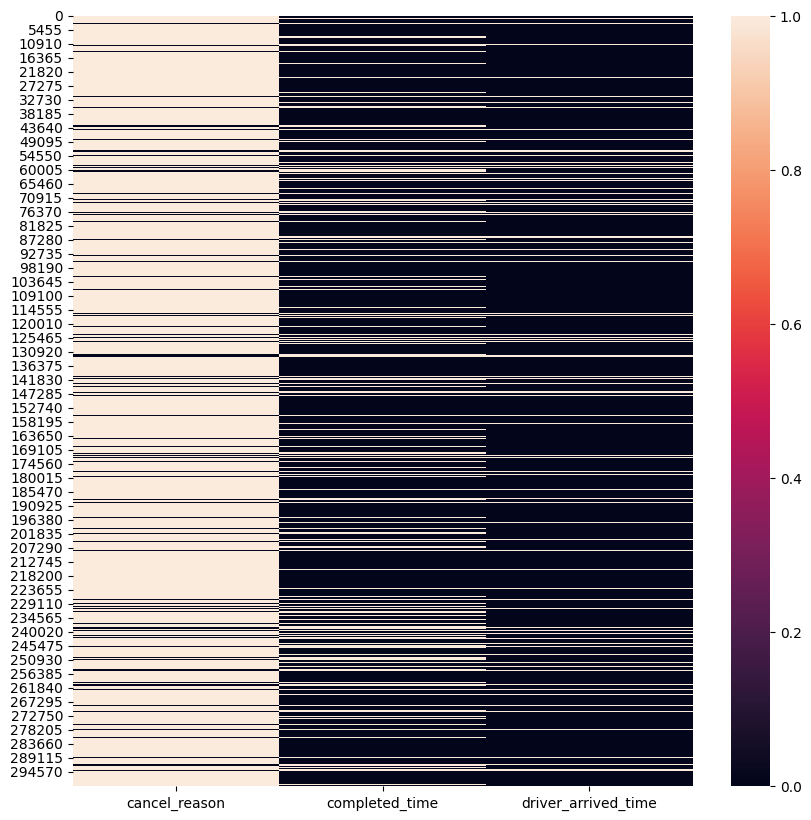

In [10]:
# sebaran missing value
plt.figure(figsize=(10,10))
sns.heatmap(df[['cancel_reason','completed_time','driver_arrived_time']].isna())


# siku dalam : utk list nama kolom nya
# contoh: df[A] >> hanya bentuk list, value si kolom A
# siku luar : utk operator pencarian / indeks di pandas utk si df
# contoh : df[[A]] >> ngembaliin ke bantuk 2 dimensi dataframe (tabel)

- Missing value teridentifikasi di 3 kolom dengan prosentase berbeda: `cancel_reason` tertinggi pada 88.07 %, `completed_time` sebesar 19.97 %, dan terendah `driver_arrived_time` sebesar 9.89 %.
- Dari sebaran data terlihat pada umumnya pesanan yang berhasil (terdapat `completed_time`), tidak memiliki data `cancel_reason`, begitu juga sebaliknya.

Ada beberapa cara mengatasi missing value, yaitu:
- Menghapus baris/kolom yang berisi missing value, namun dengan kondisi sekitar >= 10% data, hal ini harus dikaji lebih dalam terlabih dahulu, dan tidak dijadikan sebagai solusi utama. Namun jika data dipastikan tidak berpengaruh pada proses analisis, maka dapat dihapus.
- Mengisi missing value dengan data lain berdasarkan domain knowledge, dapat dengan data sebenarnya ataupun yang mendekati. Karena kolom dengan missing value memiliki tipe data object, maka dapat diisi dengan modus atau data baru.


### 1. `cancel_reason`

In [11]:
df['cancel_reason'].value_counts(dropna=False)

cancel_reason
NaN                      264220
Resto Tutup               11920
Resto Tidak Ditemukan     11808
Driver Terlalu Jauh        6036
Menu Habis                 6016
Name: count, dtype: int64

[Jenis `cancel_reason`](https://help.grab.com/driver/id-id/360042710092-Bagaimana-cara-membatalkan-orderan-GrabFood)
- **NaN** : pesanan berhasil dilakukan atau hanya bisa dilakukan sistem (sistem otomatis / Customer Service, contoh: timeout konfirmasi pesanan oleh merchant, atau tidak kunjung dapat driver), missing value ini merupakan komposisi yang mendominasi mencapai 88%.
- **Resto Tutup** : dapat dilakukan oleh driver
- **Resto Tidak Ditemukan** : dapat dilakukan oleh driver
- **Menu Habis** : resto via driver (umumnya resto menginfokan driver jika menu yang dipesan habis, driver melakukan cancel melalui aplikasi)
- **Driver Terlalu Jauh** : dapat dilakukan oleh pelanggan

Cancelation Rate
- Terlihat bahwa banyak pesanan yang dibatalkan karena Resto Tutup & Tidak Ditemukan (sekitar 8-7% dari keseluruhan data), hal ini kemungkinan karena kelalaian merchant dalam memperbarui status operasional secara real-time, gangguan sistem, serta masalah lokasi fisik

Sebelum memutuskan solusi untuk mengatasi missing value, mari lihat keterkaitan dengan kolom lain yang juga memiliki missing value.

In [12]:
# mengumpulkan semua baris yang memiliki `cancel_reason`, `completed_time`, dan `driver_arrived_time` missing value bersamaan

df_nanrow = df[df['cancel_reason'].isna() & df['completed_time'].isna() & df['driver_arrived_time'].isna()]
df_nanrow.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
11,GF-05325,GB-009244,Cancel,20000,NaN,2023-12-17 17:00:00,NaN,NaN
48,GF-05860,GB-000154,batal,0,NaN,2024-02-12 14:47:00,NaN,NaN
50,GF-06715,GB-018958,batal,30000,NaN,2023-11-14 07:45:00,NaN,NaN
56,GF-07056,GB-009382,Failed,15000,NaN,2024-03-10 14:45:00,NaN,NaN
68,GF-01066,GB-028458,CANCELED,20000,NaN,2023-11-18 15:23:00,NaN,NaN


In [13]:
df_nanrow['order_status'].unique()

array(['Cancel', 'batal', 'Failed', 'CANCELED'], dtype=object)

In [14]:
print(f'Transaction amount with missing value : {len(df_nanrow)} rows, equals to {(len(df_nanrow)/df.shape[0]*100):.2f}% data.')

Transaction amount with missing value : 11966 rows, equals to 3.99% data.


Dapat disimpulkan bahwa semua data yang memiliki `cancel_reason`, `completed_time`, dan `driver_arrived_time` missing value bersamaan merupakan data yang dibatalkan oleh sistem (dengan status : 'Cancel', 'batal', 'Failed', 'CANCELED'). Sehingga, dalam data ini dipastikan tidak ada fraud, namun data tidak dapat memberikan informasi terkait alasan pembatalan sistem.

Solusi yang diambil untuk 11966 baris data ini adalah dengan dihapus.

In [15]:
df = df.drop(df_nanrow.index)
df.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-06555,GB-019659,Completed,0,NaN,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaN
2,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaN
3,GF-05867,GB-021929,Completed,30000,NaN,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-06915,GB-008802,DONE,0,NaN,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


In [16]:
len(df)

288034

In [17]:
df['cancel_reason'].value_counts(dropna=False)

cancel_reason
NaN                      252254
Resto Tutup               11920
Resto Tidak Ditemukan     11808
Driver Terlalu Jauh        6036
Menu Habis                 6016
Name: count, dtype: int64

In [18]:
df.loc[df['cancel_reason'].isna(), 'cancel_reason']='Tidak Ada'
df['cancel_reason'].value_counts()

cancel_reason
Tidak Ada                252254
Resto Tutup               11920
Resto Tidak Ditemukan     11808
Driver Terlalu Jauh        6036
Menu Habis                 6016
Name: count, dtype: int64

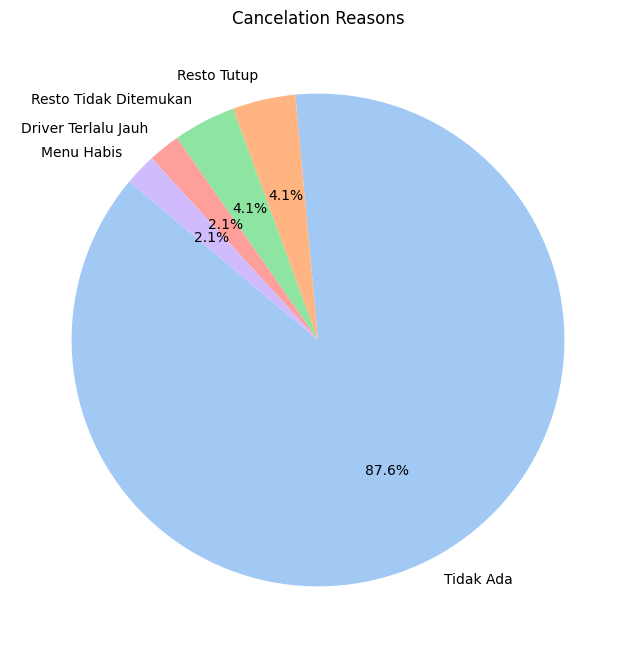

In [19]:
pie_cancel = df['cancel_reason'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    pie_cancel.values,
    labels=pie_cancel.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)

plt.title('Cancelation Reasons')
plt.show()

Kolom `cancel_reason` sudah dibersihkan
- Missing value sudah diganti dengan 'Tidak Ada'
- Tidak terdapat anomali pada data
- Penyebab Cancel tertinggi  adalah Resto tutup & tidak ditemukan

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288034 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   merchant_id          288034 non-null  object
 1   user_id              288034 non-null  object
 2   order_status         288034 non-null  object
 3   promo_discount       288034 non-null  int64 
 4   cancel_reason        288034 non-null  object
 5   order_time           288034 non-null  object
 6   driver_arrived_time  270320 non-null  object
 7   completed_time       240093 non-null  object
dtypes: int64(1), object(7)
memory usage: 19.8+ MB


### 2. `order_time`, `driver_arrived_time` & `completed_time`
- Data waktu pada ketiga kolom ini, sudah secara sistem terisi atau kosong/NaN (jika cancel/failed)
- diketahui kolom `driver_arrived_time` & `completed_time` memiliki missing value, sedangkan `order_time` tidak ada
- Untuk mempertahankan kesragaman tipe data (kedua tabel ini memiliki tipe data object, dan akan diubah menjadi datetime untuk analisis data)

In [21]:
df[['order_time', 'driver_arrived_time', 'completed_time']].dtypes

order_time             object
driver_arrived_time    object
completed_time         object
dtype: object

In [22]:
df.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-06555,GB-019659,Completed,0,Tidak Ada,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaN
2,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaN
3,GF-05867,GB-021929,Completed,30000,Tidak Ada,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-06915,GB-008802,DONE,0,Tidak Ada,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


In [23]:
driverTime_nan = df['driver_arrived_time'].isna().sum()
completeTime_nan = df['completed_time'].isna().sum()

print(f'driver_arrived_time has {driverTime_nan} missing value, equals to {(driverTime_nan/df.shape[0]*100):.2f}% data.')
print(f'completed_time has {completeTime_nan} missing value, equals to {(completeTime_nan/df.shape[0]*100):.2f}% data.')

driver_arrived_time has 17714 missing value, equals to 6.15% data.
completed_time has 47941 missing value, equals to 16.64% data.


- Diketahui terdapat pesanan yang tidak diselesaikan meskipun driver sudah sampai resto tujuan melalui missing value `completed_time` yang lebih banyak daripada `driver_arrived_time`.
- Data Type kedua kolom ini adalah object yang seharusnya datetime, sehingga harus diubah.
- Untuk menjaga tipe data datetime, maka missing value akan tetap dibiarkan (jika diisi apapun, mak perubahan menjadi datetime tidak berhasil)

In [24]:
timeColumn = ['order_time','driver_arrived_time', 'completed_time']

for column in timeColumn:
    df[column] = pd.to_datetime(df[column])

In [25]:
# [ns] yg muncul maksudnya nanosecond, menunjukkan presisi waktu terkecil
df[['order_time', 'driver_arrived_time', 'completed_time']].dtypes

order_time             datetime64[ns]
driver_arrived_time    datetime64[ns]
completed_time         datetime64[ns]
dtype: object

In [26]:
df.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-06555,GB-019659,Completed,0,Tidak Ada,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT
2,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaT
3,GF-05867,GB-021929,Completed,30000,Tidak Ada,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-06915,GB-008802,DONE,0,Tidak Ada,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


- Kolom 'order_time', `driver_arrived_time` & `completed_time` sudah berubah menjadi datetime
- NaN barubah menjadi NaT (Not a Time)

## 3. `order_status`
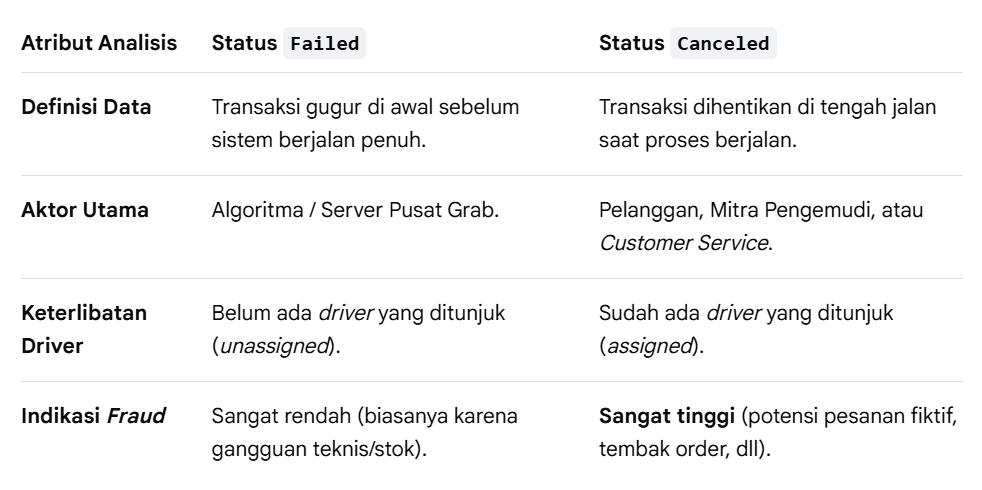

In [27]:
df['order_status'].value_counts(dropna=False)

order_status
Completed    179697
Selesai       30217
DONE          30179
Failed        12048
CANCELED      12024
Cancel        11963
batal         11906
Name: count, dtype: int64

In [28]:
df.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-06555,GB-019659,Completed,0,Tidak Ada,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT
2,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaT
3,GF-05867,GB-021929,Completed,30000,Tidak Ada,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-06915,GB-008802,DONE,0,Tidak Ada,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


- Memiliki data yang tidak konsisten dan tidak ada missing values
- Dilakukan penyeragaman data dengan makna yang sama
- Khusus untuk canceled/cancel/batal/failed harus diteliti lebih dahulu, meskipun failed/cancel karena sistem sudah dieliminasi pada tahap data preprocessing tabel `cancel_reason`
- Kegagalan oleh sistem biasanya ditunjukkan dengan proses yang belum sempurna berjalan karena timeout respon resto/driver. Maka bisa dicari tahu dengan memastikan bahwa `order_status` fail/cancel memiliki `order_time` & `driver_arrived_time` yang memiliki missing value dengan `cancel_reason` yang berasal dari subjek hukum (manusia, dalam konteks data analisis disini adalah driver/user)

note:
- Failed : biasa diartikan kegagalan dari sistem
- Canceled : biasa diartikan sebagai pembatalan dari instruksi subjek (manusia)

In [29]:
df_bySystem = df[df['completed_time'].isna() & df['driver_arrived_time'].isna()]
df_bySystem.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
15,GF-02952,GB-028833,CANCELED,10000,Resto Tutup,2023-11-02 17:17:00,NaT,NaT
25,GF-05029,GB-025202,CANCELED,0,Driver Terlalu Jauh,2023-12-27 21:47:00,NaT,NaT
30,GF-00846,GB-014120,batal,15000,Driver Terlalu Jauh,2024-02-06 18:35:00,NaT,NaT
57,GF-07642,GB-015560,Failed,15000,Resto Tidak Ditemukan,2024-02-09 15:56:00,NaT,NaT
61,GF-04745,GB-029605,Cancel,0,Resto Tidak Ditemukan,2024-02-28 13:08:00,NaT,NaT


In [30]:
# di value_counts, klo gapake () nanti dia ngitung perbaris

df_bySystem['cancel_reason'].value_counts()

cancel_reason
Resto Tidak Ditemukan    5924
Resto Tutup              5794
Driver Terlalu Jauh      3032
Menu Habis               2964
Name: count, dtype: int64

- Dapat dipastikan bahwa semua jenis pesanan yang dibatalkan/gagal bermakna batal yang dilakukan oleh driver/user dan diseragamkan menjadi Canceled
- Semua pesanan yang barhasil/sukses dapat langsung diseragamkan menjadi Completed

In [31]:
complete = ['Selesai', 'DONE']
cancel = ['Failed', 'CANCELED', 'Cancel', 'batal']

df['order_status'] = df['order_status'].replace(complete, 'Completed')
df['order_status'] = df['order_status'].replace(cancel, 'Canceled')
df['order_status'].value_counts(dropna=False)

order_status
Completed    240093
Canceled      47941
Name: count, dtype: int64

In [32]:
df.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-06555,GB-019659,Completed,0,Tidak Ada,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-07698,GB-019520,Canceled,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT
2,GF-02054,GB-030006,Canceled,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaT
3,GF-05867,GB-021929,Completed,30000,Tidak Ada,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-06915,GB-008802,Completed,0,Tidak Ada,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


## 4. `promo_discount`
- Satu-satunya data bertipe integer
- Memiliki rentang yang sangat jauh, namun untuk data bernilai 0 sangat wajar karena dapat diasumsikan pesanan tersebut tidak mendapat diskon / bukan member GrabUnlimited
- Namun kita tidak dapat mengetahui apakah diskon yang diberikan wajar atau tidak dari nominal total pesanan per `order_id`, karena tidak ada informasi pendukung, tapi kita dapat asumsikan dari nominal yang kemungkinan menjadi outlier


In [33]:
df['promo_discount'].value_counts()

promo_discount
 0          110628
 10000       55007
 20000       41232
 15000       41159
 30000       37240
 9999999      1425
-5000         1343
Name: count, dtype: int64

- Nilai `promo_discount` 9999999 kemungkinan merupakan [sentinel value](https://en.wikipedia.org/wiki/Sentinel_value) yang secara sengaja dibuat paling berbeda dan tidak mungkin dapat dicapai oleh nominal diskon pada membership GrabUnlimited (tujuan penggunaan sentinel value ini tidak diinformasikan pada dataset `grab_food_orders.csv`).
- Nilai `promo_discount` -5000 kemungkinan merupakan Modul pemotongan biaya kirim dari GrabUnlimited, biaya kirim ini biasanya bersifat langsung mengurangi total biaya ahir pada aplikasi user (konsumen) sehngga dinotasikan minus, agar kalkulator backend dapat langsung menjumlahkannya secara berderet tanpa perlu mengubah tanda operator lagi. (contoh: Total Belanja = Harga Makanan + Ongkir + (-5000)). Nilai ini dapat diseragamkan menjadi absolut seperti nominal diskon lainnya.

### Anomaly 9999999

In [34]:
df_anomaly = df[df['promo_discount'] == 9999999]
df_anomaly.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
74,GF-05357,GB-035465,Completed,9999999,Tidak Ada,2023-11-10 21:35:00,2023-11-10 21:47:00,2023-11-10 22:19:00
93,GF-01601,GB-001879,Completed,9999999,Tidak Ada,2024-01-11 13:36:00,2024-01-11 13:52:00,2024-01-11 14:16:00
254,GF-00905,GB-007683,Completed,9999999,Tidak Ada,2023-11-21 13:33:00,2023-11-21 13:41:00,2023-11-21 14:07:00
732,GF-03088,GB-027771,Completed,9999999,Tidak Ada,2024-01-26 08:17:00,2024-01-26 08:29:00,2024-01-26 08:57:00
816,GF-01160,GB-006528,Completed,9999999,Tidak Ada,2023-11-15 16:41:00,2023-11-15 16:47:00,2023-11-15 17:05:00


In [35]:
df_anomaly['order_status'].value_counts(dropna=False)

order_status
Completed    1176
Canceled      249
Name: count, dtype: int64

In [36]:
len(df_anomaly['user_id'].unique())

1400

In [37]:
df_anomaly['user_id'].value_counts(dropna=False)

user_id
GB-017775    2
GB-006374    2
GB-007977    2
GB-004966    2
GB-026901    2
GB-015527    2
GB-001120    2
GB-034016    2
GB-018049    2
GB-000983    2
GB-019420    2
GB-038009    2
GB-000553    2
GB-039914    2
GB-005205    2
GB-007371    2
GB-030863    2
GB-031980    2
GB-020881    2
GB-036680    2
GB-019025    2
GB-009498    2
GB-002000    2
GB-015842    2
GB-028771    2
GB-002277    1
GB-001235    1
GB-009877    1
GB-013265    1
GB-019695    1
GB-033193    1
GB-007037    1
GB-030626    1
GB-006858    1
GB-011586    1
GB-027771    1
GB-022107    1
GB-014046    1
GB-021274    1
GB-024141    1
GB-027168    1
GB-001918    1
GB-033808    1
GB-007582    1
GB-011175    1
GB-032559    1
GB-011420    1
GB-021572    1
GB-018140    1
GB-026993    1
GB-018434    1
GB-033445    1
GB-017229    1
GB-036817    1
GB-030596    1
GB-020509    1
GB-017423    1
GB-000671    1
GB-025026    1
GB-003147    1
GB-012575    1
GB-003224    1
GB-038330    1
GB-005996    1
GB-010098    1
GB-005085    1
GB

In [38]:
len(df_anomaly['merchant_id'].unique())

1294

In [39]:
df_anomaly['merchant_id'].value_counts(dropna=False)

merchant_id
GF-03353    3
GF-01601    3
GF-06198    3
GF-00361    3
GF-05716    3
GF-05168    3
GF-07537    2
GF-07012    2
GF-04485    2
GF-04253    2
GF-01948    2
GF-00022    2
GF-01485    2
GF-06322    2
GF-07796    2
GF-07563    2
GF-06670    2
GF-04550    2
GF-00603    2
GF-05110    2
GF-02842    2
GF-04288    2
GF-07818    2
GF-00647    2
GF-03966    2
GF-07849    2
GF-01683    2
GF-02933    2
GF-07078    2
GF-03221    2
GF-07820    2
GF-04124    2
GF-01330    2
GF-07575    2
GF-01164    2
GF-04795    2
GF-02734    2
GF-06393    2
GF-07307    2
GF-03540    2
GF-06071    2
GF-02580    2
GF-02240    2
GF-07910    2
GF-03125    2
GF-03368    2
GF-06923    2
GF-03965    2
GF-00615    2
GF-03809    2
GF-05672    2
GF-00751    2
GF-06354    2
GF-02600    2
GF-00995    2
GF-00286    2
GF-04360    2
GF-01734    2
GF-05069    2
GF-04310    2
GF-03525    2
GF-07656    2
GF-03382    2
GF-00135    2
GF-07010    2
GF-01292    2
GF-00336    2
GF-05314    2
GF-03945    2
GF-02362    2
GF-06994

- Jika asumsi awal pesanan Canceled dnegan diskon 9999999 dianggap sebagai fraud, biasanya jumlah yang terjadi akan banyak. Namun data canceled hanya sebanyak 249, jika dibandingkan dengan seluruh data sebanyak 300.000, prosentasenya tidak sampai 1 persen, sehingga terindikasi sebagai pesanan yang benar terjadi
- Dilihat dari komposisi keseluruhan `user_id` & `merchant_id` yang menunjukkan tidak ada kecenderungan pesanan berulang banyak, serta kolom lain yang tampil normal (tidak ada anomali lain), sehingga dapat diasumsikan sebagai pesanan yang benar terjadi.
- Anomali 9999999 dapat diganti menjadi 0, karena besar kemungkinan sebenarnya tidak menggunakan diskon sama sekali, sedangkan diskon muncul pada data sebagai nominal (bukan 0). Sayangnya tidak ada data total pembayaran yang dapat memberikan dukungan lebih pada argumen ini.

In [40]:
# penggantian 9999999 dan -5000
df['promo_discount'] = df['promo_discount'].replace(9999999, 0)
df['promo_discount'] = df['promo_discount'].abs()
df['promo_discount'].value_counts()

promo_discount
0        112053
10000     55007
20000     41232
15000     41159
30000     37240
5000       1343
Name: count, dtype: int64

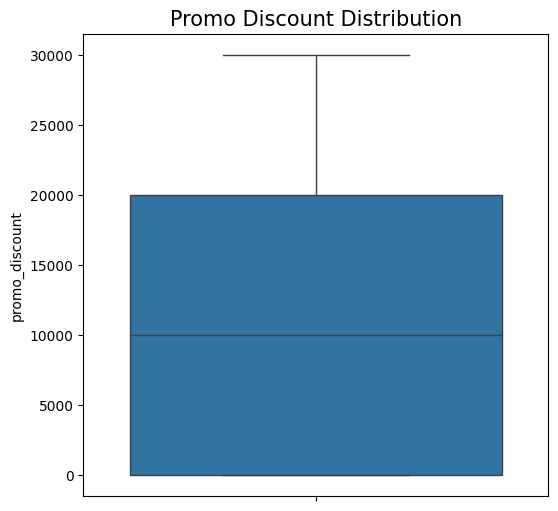

In [41]:
plt.figure(figsize=(6,6))
sns.boxplot(y = df['promo_discount'])
plt.title('Promo Discount Distribution', size =15)
plt.show()

Distribusi data `promo_discount` menjadi normal.

# Clean Data

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288034 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   merchant_id          288034 non-null  object        
 1   user_id              288034 non-null  object        
 2   order_status         288034 non-null  object        
 3   promo_discount       288034 non-null  int64         
 4   cancel_reason        288034 non-null  object        
 5   order_time           288034 non-null  datetime64[ns]
 6   driver_arrived_time  270320 non-null  datetime64[ns]
 7   completed_time       240093 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(1), object(4)
memory usage: 19.8+ MB


In [43]:
display(df.describe(include='object'))
display(df.describe().style.format('{:.0f}'))

,merchant_id,user_id,order_status,cancel_reason
count,288034,288034,288034,288034
unique,8000,39975,2,5
top,GF-02769,GB-004076,Completed,Tidak Ada
freq,61,21,240093,252254


,promo_discount,order_time,driver_arrived_time,completed_time
count,288034,288034,270320,240093
mean,10818,.0f,.0f,.0f
min,0,.0f,.0f,.0f
25%,0,.0f,.0f,.0f
50%,10000,.0f,.0f,.0f
75%,20000,.0f,.0f,.0f
max,30000,.0f,.0f,.0f
std,10390,nan,nan,nan


Sebelum data dibersihkan, terdapat 300.000 baris, sekarang terdapat 288.034 baris. Dari hasil Data Preprocessing, sekitar 12.000 data yang telah dihapus, missing value diisi dengan data yang relevan, dan pada data bertipe datetime sengaja dibiarkan terdapat baris yang kosong agar tidak merubah tipe data dan mempermudah dalam proses analisis data.

# Data Analysis
Terdapat beberapa kemungkinan pesanan yang terindikasi sebagai fraud dari dataset:
- Fraudster yang memanfaatkan diskon GrabUnlimited (`promo_discount` != 0) biasanya harus menunggu sampai status pesanan **Completed** agar subsidi diskon dapat dicairkan, dari hal ini kita sudah bisa mengidentifikasi karakter pesanan yang terindikasi sebagai fraud
- Akun yang baru dibuat, namun sudah banyak melakukan transaki menggunakan diskon
- Waktu transaksi tidak logis (jam yang tidak wajar resto buka)
- Durasi pengantaran yang terlalu cepat, bahkan selesai sebelum driver sampai

## 1. `completed_time`, `driver_arrived_time` & `order_status`
- sebelum melakukan analisis, dipastikan terlebih dahulu bahwa data `driver_arrived_time` dan/ `completed_time` yang NaT sudah benar berstatus Canceled.
- Data yang digunakan pada analisis ini, menggunakan data berstatus pesana (`order_status`) Completed.

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288034 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   merchant_id          288034 non-null  object        
 1   user_id              288034 non-null  object        
 2   order_status         288034 non-null  object        
 3   promo_discount       288034 non-null  int64         
 4   cancel_reason        288034 non-null  object        
 5   order_time           288034 non-null  datetime64[ns]
 6   driver_arrived_time  270320 non-null  datetime64[ns]
 7   completed_time       240093 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(1), object(4)
memory usage: 19.8+ MB


In [45]:
df['order_status'].value_counts(dropna=False)

order_status
Completed    240093
Canceled      47941
Name: count, dtype: int64

### NaT `completed_time`
- Perlu dipastikan dahulu bahwa semua data `completed_time` yang NaT berstatus Canceled
- Sesuai dengan kaidahnya bahwa pesanan dianggap berhasil jika terdapat `completed_time`

In [46]:
print(f'NaT driver_arrived_time : {df['driver_arrived_time'].isna().sum()}')
print(f'NaT completed_time : {df['completed_time'].isna().sum()}')

NaT driver_arrived_time : 17714
NaT completed_time : 47941


In [47]:
df_nat1 = df[df['completed_time'].isna()]
df_nat1['order_status'].value_counts(dropna=False)

order_status
Canceled    47941
Name: count, dtype: int64

In [48]:
# Pengecekan status kedua data `driver_arrived_time` & `completed_time` yang kosong (NaT)

df_nat = df[ (df['driver_arrived_time'].isna()) & (df['completed_time'].isna())]
print(df_nat['order_status'].value_counts(dropna=False))

order_status
Canceled    17714
Name: count, dtype: int64


- Semua data `driver_arrived_time` yang kosong, memiliki `completed_time` juga dipastikan kosong, serta bertatus Canceled.
- Seluruh data berstatus Canceled (47.941) termasuk sebagai pembatalan karena proses pesanan yang tidak selesai, sekitar 37% (17.714) dari termasuk pembatalan karena pesanan tidak dijemput driver (driver tidak sampai resto).
- Telah dipastikan bahwa semua data `completed_time` yang NaT berstatus Canceled dan sesuai kaidah, sehingga ada indikas fraud.

### NaT `driver_arrived_time`

In [49]:
# Pengecekan `driver_arrived_time` yang NaT (kosong), seluruh datanya berstatus Canceled
df_nat2 = df[df['driver_arrived_time'].isna()]
df_nat2['order_status'].value_counts(dropna=False)

order_status
Canceled    17714
Name: count, dtype: int64

In [50]:
# Pengecekan `driver_arrived_time` yang NaT (kosong) & `order_status` Complete, dipastikan sudah bersih
df_nat2 = df[(df['order_status']=='Completed') & (df['driver_arrived_time'].isna())]
print(f'Order Status witn missing value driver arrived time : {len(df_nat2)}')

Order Status witn missing value driver arrived time : 0


In [51]:
# `completed_time` yang mendahului `driver_arrived_time`
df_driver_anomaly = df[(df['completed_time']) < (df['driver_arrived_time'])]
print(f'Order completed precedes driver arrives : {len(df_driver_anomaly)}')
print(f'Missing values : {df_driver_anomaly['completed_time'].isna().sum()}')

Order completed precedes driver arrives : 9603
Missing values : 0


In [52]:
df_driver_anomaly.head()

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
7,GF-05908,GB-004497,Completed,30000,Tidak Ada,2023-12-29 16:39:00,2023-12-29 16:58:00,2023-12-29 16:48:00
12,GF-05000,GB-003623,Completed,30000,Tidak Ada,2024-01-03 10:14:00,2024-01-03 10:24:00,2024-01-03 10:19:00
24,GF-07570,GB-013509,Completed,30000,Tidak Ada,2024-03-12 10:43:00,2024-03-12 10:53:00,2024-03-12 10:45:00
115,GF-00589,GB-012758,Completed,30000,Tidak Ada,2023-12-07 14:18:00,2023-12-07 14:29:00,2023-12-07 14:17:00
139,GF-03538,GB-028486,Completed,30000,Tidak Ada,2024-01-23 14:52:00,2024-01-23 15:06:00,2024-01-23 14:54:00


In [53]:
df_driver_anomaly['order_status'].value_counts()

order_status
Completed    9603
Name: count, dtype: int64

In [54]:
df_driver_anomaly['promo_discount'].value_counts()

promo_discount
30000    9603
Name: count, dtype: int64

- Terdapat pesanan yang terindikasi fraud, dengan adanya 9603 data dengan anomali pesanan diterima (`completed_time`) sebelum driver sampai di resto/user (`driver_arrived_time`). Dimana, semua data tersebut memiliki status Completed & diskon sebesar 30.000
- Hal ini menunjukkan semua indikasi fraud yang terjadi memang membutuhkan [proses pesanan yang selesai sepenuhnya, agar subsidi diskon dapat dicairkan di hari berikutnya](https://help.grab.com/merchant/id-id/360043429672-Proses-Pembayaran-di-GrabFood).
- Semua data `driver_arrived_time` NaT (kosong) sudah teridentifikasi sebagai pesanan yang sesuai berstatus Canceled, sehingga tidak ditemukan bukti adanya fraud, dan sistem berjalan dengan benar (tanpa adanya anomali).
- Sehingga membuktikan semua data `completed_time`yang mendahului `driver_arrived_time` adalah fraud. Terdapat 9.603 transaksi dengan diskon yang sam asemua yaitu 30.000, sehingga total kerugian yang diperkirakan adalah Rp 288.090.000


## 2. `user_id` & `merchant_id`
- Terdapat tambahan data untuk ID yang diambil dari dataset berbeda, sehingga harus dilakukan import data dahulu.

In [55]:
# import data pendukung user_id
user_csv = pd.read_csv('grab_users.csv')
df_user = user_csv.copy().drop_duplicates(subset=['user_id'])

display(df_user.describe(include='object'))
display(df_user.describe().style.format('{:.0f}'))

,user_id
count,40000
unique,40000
top,GB-000001
freq,1


,account_age_days
count,40000
mean,751
std,431
min,1
25%,378
50%,753
75%,1122
max,1499


In [56]:
# import data pendukung merchant_id
merchant_csv = pd.read_csv('grab_merchants.csv')
df_merchant = merchant_csv.copy().drop_duplicates(subset=['merchant_id'])

display(df_merchant.describe(include='object'))

,merchant_id,merchant_name,cuisine_type,city
count,8000,8000,8000,8000
unique,8000,8000,6,10
top,GF-00001,Resto GrabMantap 0,Ayam Geprek,Bekasi
freq,1,1,1388,861


In [57]:
# merge df_driver_anomaly (terindikasi fraud) dengan kedua tabel diatas
# backlash buat ngasih tau program klo kita mau putus code, supya rapi dilanjutin di bawahnya

df_merge = pd.merge(df_driver_anomaly, df_user, on='user_id', how='left') \
             .merge(df_merchant, on='merchant_id', how='left')

print(df_merge.info())
df_merge.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9603 entries, 0 to 9602
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   merchant_id          9603 non-null   object        
 1   user_id              9603 non-null   object        
 2   order_status         9603 non-null   object        
 3   promo_discount       9603 non-null   int64         
 4   cancel_reason        9603 non-null   object        
 5   order_time           9603 non-null   datetime64[ns]
 6   driver_arrived_time  9603 non-null   datetime64[ns]
 7   completed_time       9603 non-null   datetime64[ns]
 8   is_grab_unlimited    9603 non-null   bool          
 9   account_age_days     9603 non-null   int64         
 10  merchant_name        9603 non-null   object        
 11  cuisine_type         9603 non-null   object        
 12  city                 9603 non-null   object        
dtypes: bool(1), datetime64[ns](3), in

,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,is_grab_unlimited,account_age_days,merchant_name,cuisine_type,city
0,GF-05908,GB-004497,Completed,30000,Tidak Ada,2023-12-29 16:39:00,2023-12-29 16:58:00,2023-12-29 16:48:00,True,1372,Resto GrabMantap 5907,Beverages,Medan
1,GF-05000,GB-003623,Completed,30000,Tidak Ada,2024-01-03 10:14:00,2024-01-03 10:24:00,2024-01-03 10:19:00,True,1487,Resto GrabMantap 4999,Seafood,Bekasi
2,GF-07570,GB-013509,Completed,30000,Tidak Ada,2024-03-12 10:43:00,2024-03-12 10:53:00,2024-03-12 10:45:00,False,1048,Resto GrabMantap 7569,Fast Food,Surabaya
3,GF-00589,GB-012758,Completed,30000,Tidak Ada,2023-12-07 14:18:00,2023-12-07 14:29:00,2023-12-07 14:17:00,False,236,Resto GrabMantap 588,Fast Food,Bandung
4,GF-03538,GB-028486,Completed,30000,Tidak Ada,2024-01-23 14:52:00,2024-01-23 15:06:00,2024-01-23 14:54:00,False,239,Resto GrabMantap 3537,Martabak,Bandung


### `user_id`

In [58]:
# komposisi langganan GrabUnlimited pada dataset anomali `driver_arrived_time`
df_merge['is_grab_unlimited'].value_counts()

is_grab_unlimited
False    5843
True     3760
Name: count, dtype: int64

In [59]:
# melihat data `user_id` yang menggunakan discount pada dataset anomali `driver_arrived_time`
# apakah ada transaksi yang tidak wajar (seperti akun baru yang sudah melakukan transaksi terlalu banyak)

user_count = df_merge[['user_id', 'account_age_days', 'is_grab_unlimited']].drop_duplicates(subset='user_id')
user_count = user_count.set_index('user_id')
user_count['freq'] = df_merge['user_id'].value_counts()

user_count_sort = user_count.sort_values(by='freq', ascending=False)
print(len(user_count_sort))
display(user_count_sort.head(), user_count_sort.tail())

8534


,account_age_days,is_grab_unlimited,freq
user_id,,,
GB-023485,1435,False,4
GB-019127,155,True,4
GB-035065,1223,True,3
GB-015806,1184,True,3
GB-001227,370,False,3


,account_age_days,is_grab_unlimited,freq
user_id,,,
GB-033680,1094,False,1
GB-032309,1024,True,1
GB-001450,533,False,1
GB-035249,708,False,1
GB-002399,1476,True,1


In [60]:
user_count[['account_age_days',  'is_grab_unlimited', 'freq']].corr(method = 'spearman')

,account_age_days,is_grab_unlimited,freq
account_age_days,1.000000,-0.001534,0.017092
is_grab_unlimited,-0.001534,1.000000,0.008266
freq,0.017092,0.008266,1.000000


- Tabulasi `user_id` dan pengujian korelasi menunjukkan tidak ada hubungan (asosiasi) lamanya akun dibuat (`account_age_days`) & langgangan GrabUnlimited (`is_grab_unlimited`) terhadap frekuensi transaksi yang dilakukan.
- Namun, mengingat informasi ini diambil dari data anomali `driver_arrived_time`, maka kemungkinan fraudster menggunakan akun yang berbeda-beda, dengan memperhitungkan frekuensi penggunaan akun agar tidak terlihat mencurigakan.
- Total 9603 pesanan yang terindikasi fraud, sekitar 39% (3.760) yang berlangganan GrabUnlimited dengan kerugian yang diperkirakan sebesar Rp 112.800.000, sedangkan 61% sisanya (perkiraan kerugian sebesarRp 175.290.000) terindikasi fraud melalui celah diskon lainnya.

### `merchant_id`

In [61]:
# melihat data `merchant_id` yang menggunakan discount pada dataset anomali `driver_arrived_time`
# apakah ada `merchant_id` yang belum lama dibuat, namun sudah jumlah memiliki transaksi yang tidak wajar

merchant_count = df_merge[['merchant_id', 'cuisine_type', 'account_age_days']].drop_duplicates(subset='merchant_id')
merchant_count = merchant_count.set_index('merchant_id')
merchant_count['freq'] = df_merge['merchant_id'].value_counts()

merchant_count_sort = merchant_count.sort_values(by='freq', ascending=False)
print(len(merchant_count_sort))
display(merchant_count_sort.head(), merchant_count_sort.tail())

5635


,cuisine_type,account_age_days,freq
merchant_id,,,
GF-07819,Snacks,1024,7
GF-01160,Martabak,716,7
GF-07334,Fast Food,1059,6
GF-03661,Seafood,634,6
GF-04955,Ayam Geprek,41,6


,cuisine_type,account_age_days,freq
merchant_id,,,
GF-05788,Seafood,1094,1
GF-02836,Martabak,696,1
GF-01205,Beverages,1234,1
GF-05710,Martabak,433,1
GF-06497,Beverages,1042,1


In [62]:
merchant_count[['account_age_days',  'freq']].corr(method = 'spearman')

,account_age_days,freq
account_age_days,1.000000,-0.026668
freq,-0.026668,1.000000



- Tabulasi `merchant_id` dan pengujian korelasi menunjukkan tidak ada hubungan (asosiasi) lamanya akun dibuat (`account_age_days`) terhadap frekuensi transaksi yang dilakukan.
- Frekuensi kemunculan data `user_id` & `merchant_id` cukup merata, sehingga belum bisa diketahui akun yang paling signifikan terlihat melakukan fraud, kemungkinan fraudster melakukan aksinya dengan menggunakan banyak akun baru.
- Kemudian kita dapat mencari tau `cuisin_type` yang paling banyak digunakan sebagai kedok pembuatan merchant baru.

In [63]:
merchant_count.describe(include='object')

,cuisine_type
count,5635
unique,6
top,Ayam Geprek
freq,975


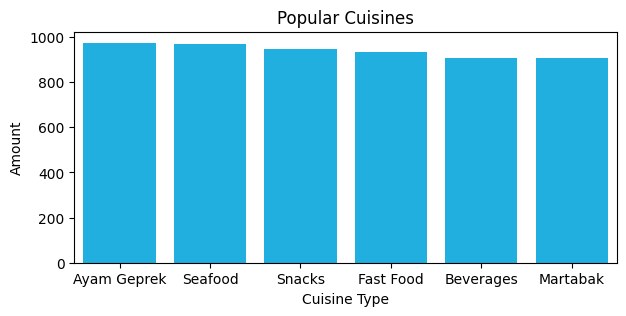

In [64]:
cuisine = merchant_count['cuisine_type'].value_counts()

plt.figure(figsize=(7,3))
sns.barplot(x=cuisine.index, y=cuisine.values, color='deepskyblue')
plt.title('Popular Cuisines')
plt.xlabel('Cuisine Type')
plt.ylabel('Amount')
plt.show()

In [65]:
df_merge['cuisine_type'].value_counts(ascending=False)

cuisine_type
Seafood        1695
Snacks         1653
Ayam Geprek    1630
Beverages      1553
Fast Food      1544
Martabak       1528
Name: count, dtype: int64

Ayam Geprek, Snack, & Seafood sebagai `cuisine_type` yang paling banyak digunakan sebagai kedok oleh fraudster. Hal ini dikarenakan volume transaksi alami yang tinggi di platform, kewajaran jam operasional merchan hingga larut malam, harga menu yang fleksible, serta didukung dengan kemudahan pendaftaran merchant. Semua ini saling mendung membuat ekosistem yang memudahkan siapapun untuk membuat merchant, baik organik maupun fiktif.

## 3. `order_time`
Mengidentifikasi waktu khusus adanya transaksi yang tidak wajar (di waktu sepi seperti dini hari), hal ini merupakan strategi fraudster dalam menjalankan rencananya, karena pada waktu ini resiko pesanan fiktif diterima driver organik lebih rendah, dapat toko fiktif lebih muah berkamuflase (jarang yang mau cek toko fisik saat dini hari), bahkan bersembunyi dari pattern yang dapat diketahui sistem.

### Transaction by hour

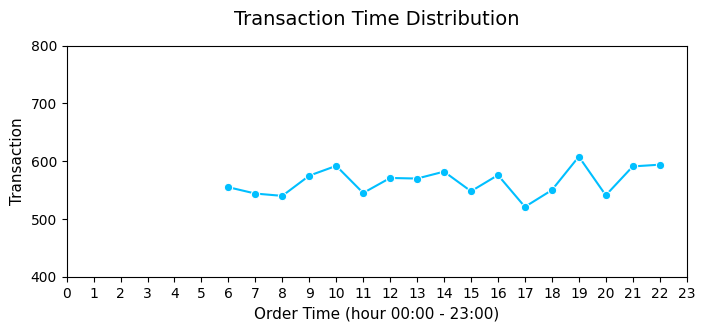

In [66]:
# menambahkan kolom baru untuk mengelompokkan jam transaksi
df_merge['order_hour'] = df_merge['order_time'].dt.hour
hour = df_merge['order_hour'].value_counts().sort_index()

plt.figure(figsize=(8,3))
sns.lineplot(x=hour.index, y=hour.values, marker='o', color='deepskyblue')
plt.title('Transaction Time Distribution', fontsize=14, pad=15)
plt.xlabel('Order Time (hour 00:00 - 23:00)', fontsize=11)
plt.ylabel('Transaction', fontsize=11)
plt.xticks(range(0,24))
plt.yticks(range(400,801,100))
plt.show()

In [67]:
# chisquare goodness of fit, utk liat pola persebaran
# h0 = distribudi data merata
# ha = distribusi data tidak merata

order_hour_freq = df_merge['order_hour'].value_counts().sort_index().values

chi2_stat, p_value = chisquare(order_hour_freq)
print(f'chisquare statistik : {chi2_stat:.4f}')
print(f'P-value             : {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('Kesimpulan: Tolak H0, data terdistribusi TIDAK merata')
else:
    print('Kesimpulan: Terima H0, data terdistribusi MERATA')

chisquare statistik : 16.3888
P-value             : 0.4262
Kesimpulan: Terima H0, data terdistribusi MERATA


- Grafik menunjukkan distribusi pembuatan pesanan pada tiap jam seluruhnya berada di kisaran 500-600 transaksi.
- Didukung dengan pengujian Chisquare Goodness of Fit yang menunjukkan hasil data berdistribusi merata.
- Transaksi tertinggi terjadi sekitar jam 19:00, diikuti transaksi tertinggi berikutnya pada jam 21:00 dan 22:00
- Meskipun transaksi tidak dilakukan pada dini hari seperti dugaan, tetapi terlihat bahwa menjelang tengah malam transaksi meningkat.

### Transaction by date

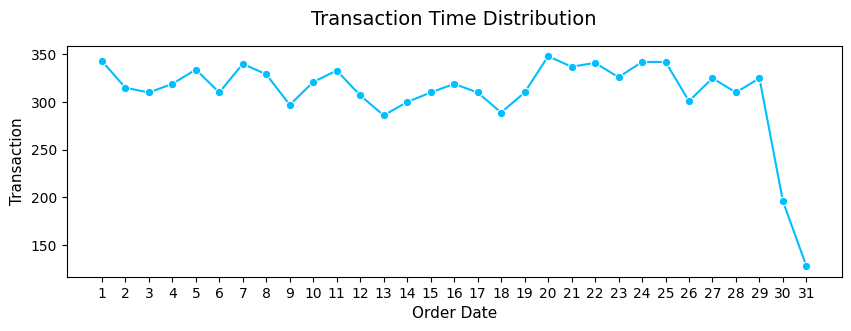

In [68]:
# menambahkan kolom baru untuk mengelompokkan tanggal transaksi
df_merge['order_day'] = df_merge['order_time'].dt.day
day = df_merge['order_day'].value_counts().sort_index()

plt.figure(figsize=(10,3))
sns.lineplot(x=day.index, y=day.values, marker='o', color='deepskyblue')
plt.title('Transaction Time Distribution', fontsize=14, pad=15)
plt.xlabel('Order Date', fontsize=11)
plt.ylabel('Transaction', fontsize=11)
plt.xticks(range(1,32))
plt.show()

In [69]:
# chisquare goodness of fit, utk liat pola persebaran
# h0 = distribudi data merata
# ha = distribusi data tidak merata

order_day_freq = df_merge['order_day'].value_counts().sort_index().values

chi2_stat, p_value = chisquare(order_hour_freq)
print(f'chisquare statistik : {chi2_stat:.4f}')
print(f'P-value             : {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('Kesimpulan: Tolak H0, data terdistribusi TIDAK merata')
else:
    print('Kesimpulan: Terima H0, data terdistribusi MERATA')

chisquare statistik : 16.3888
P-value             : 0.4262
Kesimpulan: Terima H0, data terdistribusi MERATA


- Meskipun terdapat penurunan ekstrim pada ahir bulan (tanggal 29-31), kemudian meningkat ekstrim pada awal bulan (tanggal 1), pada tanggal lainnya terlihat cukup stabil, serta secara statistik masih tergolong distribusi data yang merata.
- Dengan demikian tidak dapat disimpulkan pola pesanan berdasarkan jam dan tanggal transaksi.

# Kesimpulan & Rekomendasi
**Hasil Analisis menyimpulkan:**
- Total data memiliki 300.000 baris, yang menunjukkan adanya indikasi fraud ditemukan sebanyak 9.603 baris.
- Perkiraan total kerugian yang dialami Grab sebesar Rp 288.090.000 dengan prosentase 39% (Rp 112.800.000) dari member GrabUnlimited dan 61% (Rp 175.290.000) dari diskon lainnya.
- Indikasi fraud yang ditemukan pada data terlihat dengan adanya `completed_time` yang mendahului `driver_arrived_time`, dimana hal ini merupakan anomali dan harunya tidak mungkin terjadi dalam proses pemesana yang benar (organik). Namun, disinilah ditemukan celah yang dimanfaatkan oleh para fraudster.
- Perilaku pengguna platform `user_id` & `merchant_id` tidak memiliki pola/tendensi yang melakukan pemesanan secara frekuentif, sehingga kemungkinan sindikat fraudster mendaftar banyak akun agar pola transaksi tetap terlihat wajar. Ini juga merupakah celah yang menunjukkan kemudahan pendaftaran akun dimanfaatkan oleh fraudster, sehingga perlu adanya sistem yang lebih ketat untuk membedakan akun organik & fiktif.
- Terlihat adanya `cuisine_type` yang banyak digunakan yaitu Ayam Geprek, Snack, & Seafood, sebagai kedok pembuatan akun merchant fiktif.
- Tidak adanya pola waktu transaksi fraud yang terlihat.
- Penyebab Cancel tertinggi adalah Resto Tutup & Resto Tidak Ditemukan, hal ini sangat merugikan driver organik yang dapat mengganggu performa pencapaian hasil kerja.

**Rekomendasi yang dapat diberikan:**
- Memberlakukan prosedur pemesanan yang lebih ketat, dengan menghilangkan fitur merchant dapat menyelesaikan pemesanan meskipun driver belum sampai. Setiap proses tidak dapat dinyatakan selesai sebelum benar-benar terverifikasi.
- Pembatasan diskon / pemblokiran akun jika terdapat transaksi fiktif dengan mengidentifikasi `completed_time` & `driver_arrived_time` tidak wajar pada transaksi sebelumnya.
- Menerapkan proses verifikasi pendaftaran akun merchant yang lebih detail seperti penambahan syarat minimal lama usaha telah berjalan (bisa minimal 1 tahun), dilakukannya survei fisik secara berkala (bisa diasumsikan seperti audit tahunan), diadakannya kanal pengaduan yang dapat diisi oleh driver dengan mengharuskan dokumen pendukung (seperti foto / dokumentasi lainnya) hal ini juga dapat membantu menurunkan cancelation rate yang terjadi karena Resto Tutup & Resto Tidak Ditemukan.
- Begitu pula dengan verifikasi pendaftaran akun GrabUnlimited, dapat dibatasi oleh pengguna yang telah memiliki akun dengan syarat minimal lama AKTIF, dapat dikategorikan pulan AKTIF yang dapat diloloskan menjadi member GrabUnlimited.
- Kesimpulan lainnya untuk operasional, pada `order_status` untuk distandarisasi agar lebih mudah dalam penyimpanan data & analisis lebih lanjut, serta `cancelation_reason` yang dibuat memiliki data secara otomatis jika transaksi sukses (tidak dibiarkan kosong), seperti langsung muncul kategori 'Tidak Ada'.